In [12]:
import pandas as pd
import folium
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [13]:
df = pd.read_csv('../Datasets/Raw Datasets/stikstofdioxide-metingen.csv', sep=';')

df[['lat', 'lon']] = df['geo_point_2d'].str.split(',', expand=True).astype(float)

m = folium.Map(location=[df['lat'].mean(), df['lon'].mean()], zoom_start=12)

year_columns = [col for col in df.columns if col.startswith('20')]

for _, row in df.iterrows():
    popup_html = f"<b>{row['Location_description']}</b><br><b>{row['Neighbourhood']}</b><br><br>"
    popup_html += "<table border='1' style='border-collapse:collapse;'>"
    popup_html += "<tr><th>Year</th><th>Value</th></tr>"
    for year in year_columns:
        value = row[year]
        popup_html += f"<tr><td>{year}</td><td>{value}</td></tr>"
    popup_html += "</table>"
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=6,
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.7,
        popup=folium.Popup(popup_html, max_width=300),
        tooltip=row['Neighbourhood']
    ).add_to(m)

m



In [14]:
gdf = gpd.read_file('../Datasets/wijken.shp')

In [15]:
gdf['GM_NAAM'] = 'Eindhoven'

In [16]:
eindhoven_gdf = gdf.to_crs(epsg=4326)

In [17]:
m = folium.Map(location=[51.4416, 5.4697], zoom_start=12)

In [18]:
folium.GeoJson(
    eindhoven_gdf,
    name="Neighborhoods"
).add_to(m)

In [19]:
m

In [21]:
sensor_df = pd.read_csv('../Datasets/Raw Datasets/air_pollution_sensor_locations.csv', delimiter=',')

sensor_df['Lat'] = sensor_df['Lat']
sensor_df['Lon'] = sensor_df['Lon']

for _, row in sensor_df.iterrows():
    folium.CircleMarker(
        location=[row['Lat'], row['Lon']],
        radius=5,
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=0.8,
        popup=f"Sensor: {row['Sensor']}"
    ).add_to(m)

m

In [22]:
sensor_gdf = gpd.GeoDataFrame(
    sensor_df,
    geometry=gpd.points_from_xy(sensor_df['Lon'], sensor_df['Lat']),
    crs="EPSG:4326"
)

sensor_with_neigh = gpd.sjoin(sensor_gdf, eindhoven_gdf, how='left', predicate='within')

sensor_df['Neighbourhood'] = sensor_with_neigh['wijknaam']

sensor_df.to_csv('../Datasets/air_pollution_sensor_locations.csv', index=False)

# AIR POLLUTION EDA

In [23]:
df = pd.read_csv('../Datasets/predicted_air_pollution.csv')

In [24]:
df.describe(include='all')

,Neighbourhood,LAT,LON,PM1_mean,PM2.5_mean,PM10_mean,NO2_mean
count,116,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000
unique,116,NaN,NaN,NaN,NaN,NaN,NaN
top,Achtse Barrier-Spaaihoef,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,51.446301,5.470025,10.504114,13.052960,19.083748,21.293880
std,NaN,0.022314,0.032993,0.417092,0.456531,0.399919,1.077979
min,NaN,51.409233,5.376645,9.136034,11.520968,17.415388,17.372426
25%,NaN,51.428864,5.452224,10.218565,12.761268,18.887821,20.622750
50%,NaN,51.444290,5.473878,10.479057,12.973317,19.146444,21.279624
75%,NaN,51.462177,5.494180,10.849674,13.448420,19.305397,21.938322


In [25]:
HAMRFUL_LEVELS = {
    'PM1': 10,
    'PM2.5': 10,
    'PM10': 20,
    'NO2': 20
}

In [26]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

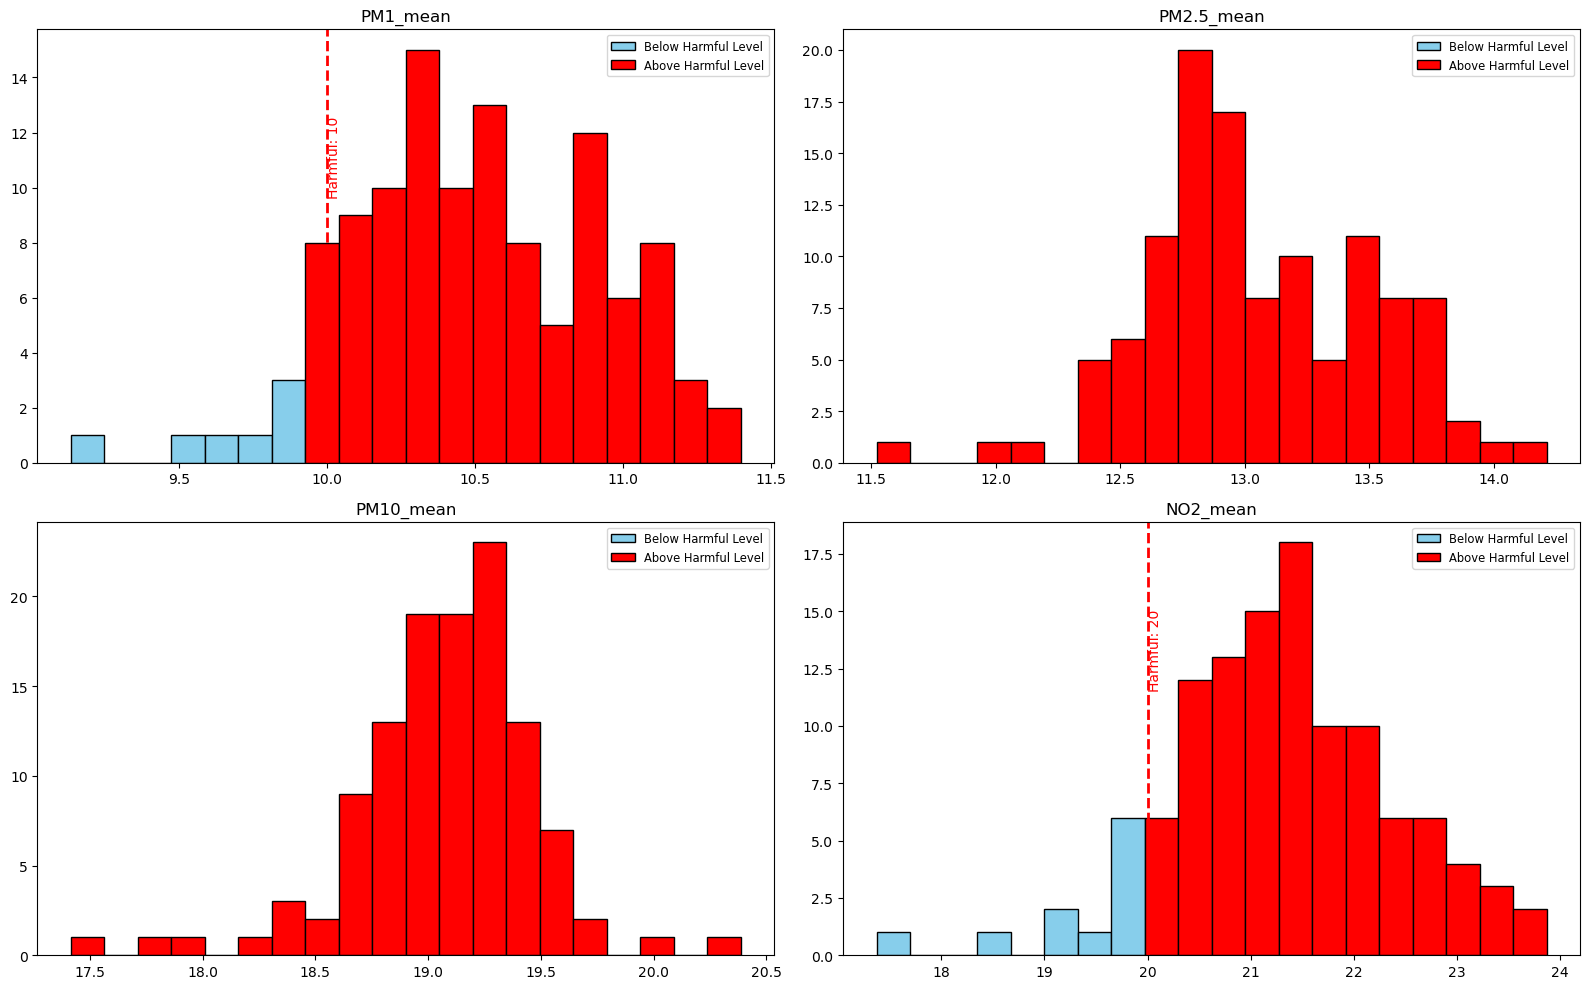

In [32]:
plot_cols = [col for col in numeric_cols if col not in ['LAT', 'LON']]

from matplotlib.patches import Patch

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    ax = axes[i]
    data = df[col].dropna()
    pollutant = None
    threshold = None
    for pol in HAMRFUL_LEVELS:
        if pol in col:
            pollutant = pol
            threshold = HAMRFUL_LEVELS[pol]
            break

    bins = 20
    counts, bin_edges = np.histogram(data, bins=bins)
    bar_colors = ['skyblue'] * bins

    if threshold is not None:
        for j in range(bins):
            if bin_edges[j] < threshold < bin_edges[j+1]:
                bar_colors[j] = 'red'
            elif bin_edges[j] >= threshold:
                bar_colors[j] = 'red'

    for j in range(bins):
        ax.bar(
            (bin_edges[j] + bin_edges[j+1]) / 2,
            counts[j],
            width=(bin_edges[j+1] - bin_edges[j]),
            color=bar_colors[j],
            edgecolor='black',
            align='center'
        )
    ax.set_title(col)

    if threshold is not None and np.nanmin(data) <= threshold <= np.nanmax(data):
        ax.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Harmful: {threshold}')
        ax.text(threshold, ax.get_ylim()[1]*0.8, f'Harmful: {threshold}', color='red', rotation=90, va='top')

    if threshold is not None:
        legend_handles = [
            Patch(facecolor='skyblue', edgecolor='black', label='Below Harmful Level'),
            Patch(facecolor='red', edgecolor='black', label='Above Harmful Level')
        ]
        ax.legend(handles=legend_handles, loc='upper right', fontsize='small')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

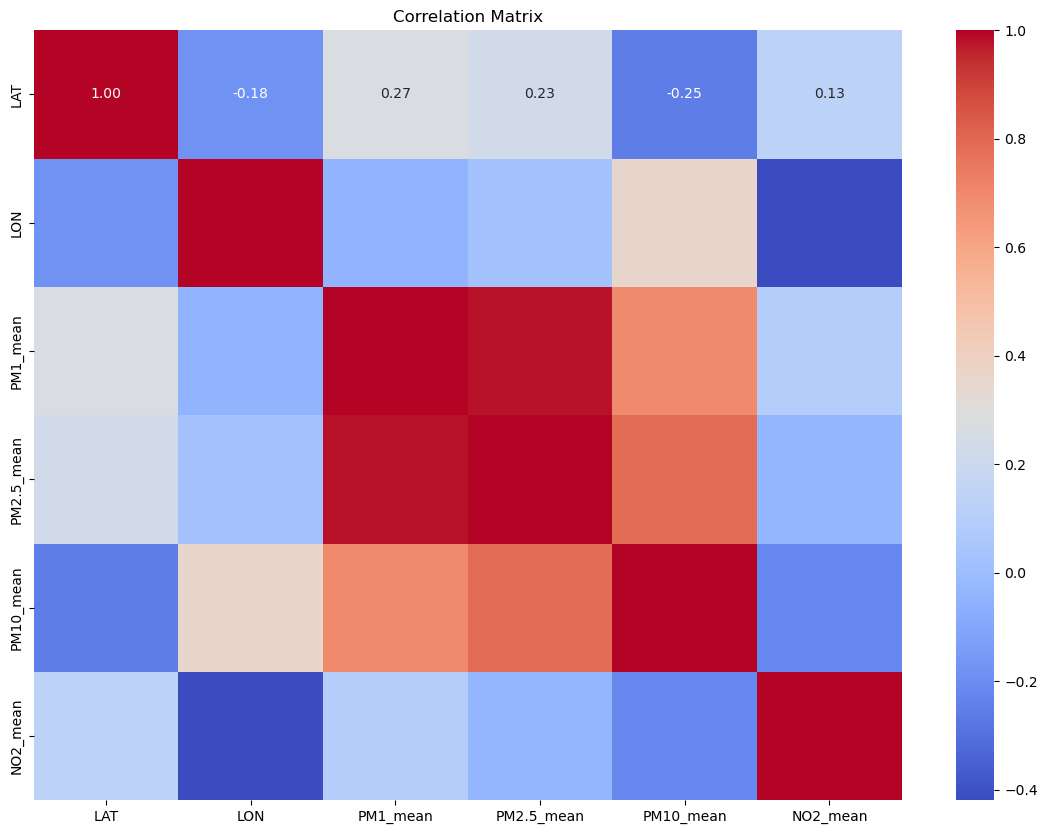

In [28]:
plt.figure(figsize=(14, 10))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [29]:
df = df.replace([np.inf, -np.inf], np.nan)

plt.figure(figsize=(12, 6))
for col in ["PM2.5_mean", "PM10_mean", "NO2_mean", "PM1_mean"]:
    sns.lineplot(data=df, x="Year", y=col, label=col)
plt.title("Pollutants Over Time")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

ValueError: Could not interpret value `Year` for parameter `x`

<Figure size 1200x600 with 0 Axes>

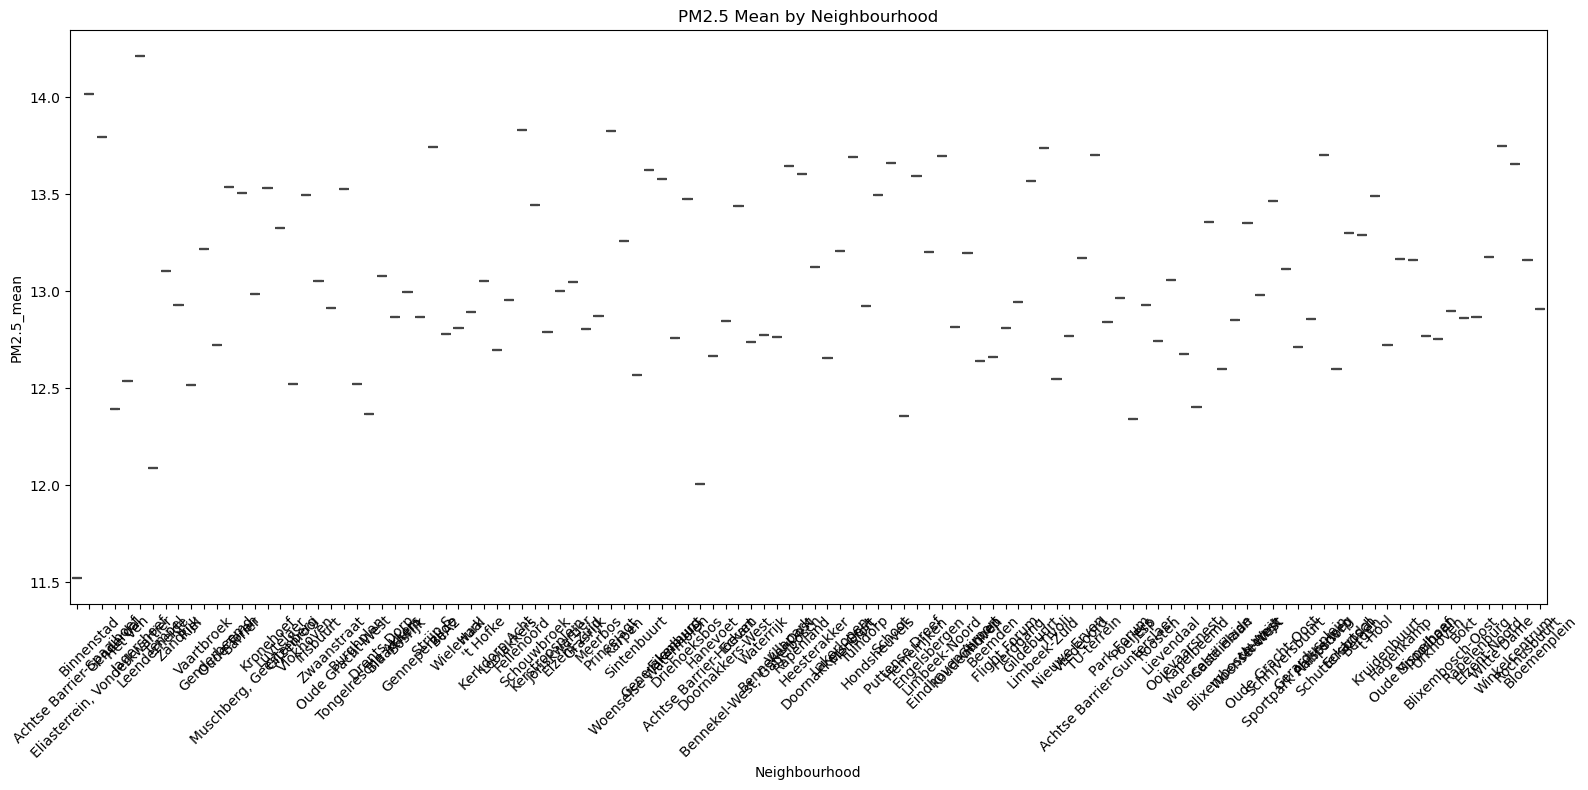

In [ ]:
plt.figure(figsize=(16, 8))
sns.boxplot(data=df, x="Neighbourhood", y="PM2.5_mean")
plt.title("PM2.5 Mean by Neighbourhood")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()